In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from adjustText import adjust_text
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid", palette="muted")

In [3]:
data = pd.read_csv('data/players.csv')

In [4]:
cols_to_drop = [
    'pens_won', 'pens_conceded', 'own_goals', 'gk_games', 'gk_games_starts',
    'gk_minutes', 'gk_goals_against', 'gk_goals_against_per90',
    'gk_shots_on_target_against', 'gk_saves', 'gk_save_pct', 'gk_wins',
    'gk_ties', 'gk_losses', 'gk_clean_sheets', 'gk_clean_sheets_pct',
    'gk_pens_att', 'gk_pens_allowed', 'gk_pens_saved', 'gk_pens_missed',
    'gk_pens_save_pct'
]

# Drop columns and assign back to dataframe
data = data.drop(columns=cols_to_drop)
data.head()

,player,team,team_country,position,age,birth_year,club,games,games_starts,minutes,minutes_90s,goals,assists,goals_assists,goals_pens,pens_made,pens_att,cards_yellow,cards_red,goals_per90,assists_per90,goals_assists_per90,goals_pens_per90,goals_assists_pens_per90,shots,shots_on_target,shots_on_target_pct,shots_per90,shots_on_target_per90,goals_per_shot,goals_per_shot_on_target,minutes_per_game,minutes_pct,minutes_per_start,games_complete,games_subs,minutes_per_sub,unused_subs,points_per_game,on_goals_for,on_goals_against,plus_minus,plus_minus_per90,plus_minus_wowy,cards_yellow_red,fouls,fouled,offsides,crosses,interceptions,tackles_won
0,Achref Abada,Algeria,Algeria,DF,26,1999,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Adil Boulbina,Algeria,Algeria,FW,23,2003,NaN,2,0,19.0,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.0,0.0,NaN,0.00,0.00,NaN,NaN,10.0,5.3,NaN,0,2,10.0,2,0.0,0.0,0.0,0.0,0.00,1.06,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,Amine Gouiri,Algeria,Algeria,FW,26,2000,Marseille,4,3,251.0,2.8,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.36,0.0,0.36,0.36,0.36,3.0,2.0,66.7,1.08,0.72,0.33,0.5,63.0,69.7,73.0,0,1,33.0,0,1.0,4.0,5.0,-1.0,-0.36,2.12,0.0,1.0,1.0,0.0,1.0,0.0,1.0
3,Anis Hadj Moussa,Algeria,Algeria,MF,24,2002,Feyenoord,3,1,98.0,1.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.00,2.0,0.0,0.0,1.84,0.00,0.00,NaN,33.0,27.2,63.0,0,2,18.0,1,1.0,1.0,2.0,-1.0,-0.92,0.11,0.0,0.0,2.0,0.0,5.0,1.0,0.0
4,Aïssa Mandi,Algeria,Algeria,DF,34,1991,Lille,4,4,360.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.0,0.0,NaN,0.00,0.00,NaN,NaN,90.0,100.0,90.0,4,0,NaN,0,1.0,5.0,9.0,-4.0,-1.00,NaN,0.0,0.0,5.0,0.0,0.0,4.0,3.0


In [5]:
data

,player,team,team_country,position,age,birth_year,club,games,games_starts,minutes,minutes_90s,goals,assists,goals_assists,goals_pens,pens_made,pens_att,cards_yellow,cards_red,goals_per90,assists_per90,goals_assists_per90,goals_pens_per90,goals_assists_pens_per90,shots,shots_on_target,shots_on_target_pct,shots_per90,shots_on_target_per90,goals_per_shot,goals_per_shot_on_target,minutes_per_game,minutes_pct,minutes_per_start,games_complete,games_subs,minutes_per_sub,unused_subs,points_per_game,on_goals_for,on_goals_against,plus_minus,plus_minus_per90,plus_minus_wowy,cards_yellow_red,fouls,fouled,offsides,crosses,interceptions,tackles_won
0,Achref Abada,Algeria,Algeria,DF,26,1999,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Adil Boulbina,Algeria,Algeria,FW,23,2003,NaN,2,0,19.0,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.0,0.0,NaN,0.00,0.00,NaN,NaN,10.0,5.3,NaN,0,2,10.0,2,0.0,0.0,0.0,0.0,0.00,1.06,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,Amine Gouiri,Algeria,Algeria,FW,26,2000,Marseille,4,3,251.0,2.8,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.36,0.0,0.36,0.36,0.36,3.0,2.0,66.7,1.08,0.72,0.33,0.5,63.0,69.7,73.0,0,1,33.0,0,1.0,4.0,5.0,-1.0,-0.36,2.12,0.0,1.0,1.0,0.0,1.0,0.0,1.0
3,Anis Hadj Moussa,Algeria,Algeria,MF,24,2002,Feyenoord,3,1,98.0,1.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.00,2.0,0.0,0.0,1.84,0.00,0.00,NaN,33.0,27.2,63.0,0,2,18.0,1,1.0,1.0,2.0,-1.0,-0.92,0.11,0.0,0.0,2.0,0.0,5.0,1.0,0.0
4,Aïssa Mandi,Algeria,Algeria,DF,34,1991,Lille,4,4,360.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.0,0.0,NaN,0.00,0.00,NaN,NaN,90.0,100.0,90.0,4,0,NaN,0,1.0,5.0,9.0,-4.0,-1.00,NaN,0.0,0.0,5.0,0.0,0.0,4.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1243,Rustam Ashurmatov,Uzbekistan,Uzbekistan,DF,29,1996,Esteghlal,3,3,256.0,2.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.0,0.0,NaN,0.00,0.00,NaN,NaN,85.0,94.8,85.0,2,0,NaN,0,0.0,2.0,10.0,-8.0,-2.81,3.62,0.0,1.0,0.0,0.0,0.0,7.0,2.0
1244,Sherzod Esanov,Uzbekistan,Uzbekistan,MF,23,2003,NaN,1,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.0,0.0,NaN,0.00,0.00,NaN,NaN,1.0,0.4,NaN,0,1,1.0,2,0.0,0.0,0.0,0.0,0.00,3.01,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1245,Sherzod Nasrullaev,Uzbekistan,Uzbekistan,"DF,MF",27,1998,NaN,3,3,180.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.00,0.0,0.00,0.00,0.00,1.0,1.0,100.0,0.50,0.50,0.00,0.0,60.0,66.7,60.0,1,0,NaN,0,0.0,1.0,7.0,-6.0,-3.00,0.00,0.0,3.0,2.0,0.0,3.0,2.0,2.0
1246,Umar Eshmurodov,Uzbekistan,Uzbekistan,DF,33,1992,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
cols_to_drop = [
    'goals_pens', 'pens_made', 'pens_att', 'goals_per90', 'assists_per90', 
    'goals_assists_per90', 'goals_pens_per90', 'goals_assists_pens_per90', 
    'shots_on_target_pct', 'shots_per90', 'shots_on_target_per90', 'minutes_pct', 
    'minutes_per_start', 'games_complete', 'games_subs', 'minutes_per_sub', 
    'unused_subs', 'on_goals_for', 'on_goals_against', 'plus_minus', 
    'plus_minus_per90', 'plus_minus_wowy'
]

# Drop columns directly and update dataframe
data = data.drop(columns=cols_to_drop, errors='ignore')

In [7]:
data.head()

,player,team,team_country,position,age,birth_year,club,games,games_starts,minutes,minutes_90s,goals,assists,goals_assists,cards_yellow,cards_red,shots,shots_on_target,goals_per_shot,goals_per_shot_on_target,minutes_per_game,points_per_game,cards_yellow_red,fouls,fouled,offsides,crosses,interceptions,tackles_won
0,Achref Abada,Algeria,Algeria,DF,26,1999,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Adil Boulbina,Algeria,Algeria,FW,23,2003,NaN,2,0,19.0,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,10.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,Amine Gouiri,Algeria,Algeria,FW,26,2000,Marseille,4,3,251.0,2.8,1.0,0.0,1.0,0.0,0.0,3.0,2.0,0.33,0.5,63.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0
3,Anis Hadj Moussa,Algeria,Algeria,MF,24,2002,Feyenoord,3,1,98.0,1.1,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.00,NaN,33.0,1.0,0.0,0.0,2.0,0.0,5.0,1.0,0.0
4,Aïssa Mandi,Algeria,Algeria,DF,34,1991,Lille,4,4,360.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,90.0,1.0,0.0,0.0,5.0,0.0,0.0,4.0,3.0


In [8]:
cols_to_drop = [
    'team_country', 
    'birth_year', 
    'games_starts', 
    'minutes_90s', 
    'goals_assists', 
    'points_per_game', 
    'cards_yellow_red'
]

# Drop columns and update dataframe
data = data.drop(columns=cols_to_drop, errors='ignore')

In [9]:
data.head()

,player,team,position,age,club,games,minutes,goals,assists,cards_yellow,cards_red,shots,shots_on_target,goals_per_shot,goals_per_shot_on_target,minutes_per_game,fouls,fouled,offsides,crosses,interceptions,tackles_won
0,Achref Abada,Algeria,DF,26,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Adil Boulbina,Algeria,FW,23,NaN,2,19.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,10.0,0.0,0.0,1.0,0.0,0.0,0.0
2,Amine Gouiri,Algeria,FW,26,Marseille,4,251.0,1.0,0.0,0.0,0.0,3.0,2.0,0.33,0.5,63.0,1.0,1.0,0.0,1.0,0.0,1.0
3,Anis Hadj Moussa,Algeria,MF,24,Feyenoord,3,98.0,0.0,0.0,0.0,0.0,2.0,0.0,0.00,NaN,33.0,0.0,2.0,0.0,5.0,1.0,0.0
4,Aïssa Mandi,Algeria,DF,34,Lille,4,360.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,90.0,0.0,5.0,0.0,0.0,4.0,3.0


In [10]:
data['player'].duplicated().sum()

np.int64(1)

In [11]:
data[data['player'].duplicated(keep=False)]

,player,team,position,age,club,games,minutes,goals,assists,cards_yellow,cards_red,shots,shots_on_target,goals_per_shot,goals_per_shot_on_target,minutes_per_game,fouls,fouled,offsides,crosses,interceptions,tackles_won
28,Emiliano Martínez,Argentina,GK,33,Aston Villa,8,810.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,101.0,0.0,1.0,0.0,0.0,0.0,0.0
1199,Emiliano Martínez,Uruguay,MF,26,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
data = data.dropna(subset=['minutes'])

In [13]:
data['goals_per_shot'] = data['goals_per_shot'].fillna(0)

In [14]:
data['goals_per_shot_on_target'] = data['goals_per_shot_on_target'].fillna(0)

In [15]:
data['club'] = data['club'].fillna('Unattached')

In [16]:
data['position'] = data['position'].str.split(',').str[0]

In [17]:
data['position'].unique()

array(['FW', 'MF', 'DF', 'GK'], dtype=object)

In [18]:
data.info()

<class 'pandas.DataFrame'>
Index: 1039 entries, 1 to 1247
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player                    1039 non-null   str    
 1   team                      1039 non-null   str    
 2   position                  1039 non-null   object 
 3   age                       1039 non-null   int64  
 4   club                      1039 non-null   str    
 5   games                     1039 non-null   int64  
 6   minutes                   1039 non-null   float64
 7   goals                     1039 non-null   float64
 8   assists                   1039 non-null   float64
 9   cards_yellow              1039 non-null   float64
 10  cards_red                 1039 non-null   float64
 11  shots                     1039 non-null   float64
 12  shots_on_target           1039 non-null   float64
 13  goals_per_shot            1039 non-null   float64
 14  goals_per_shot_on_target

<Axes: xlabel='position', ylabel='goals'>

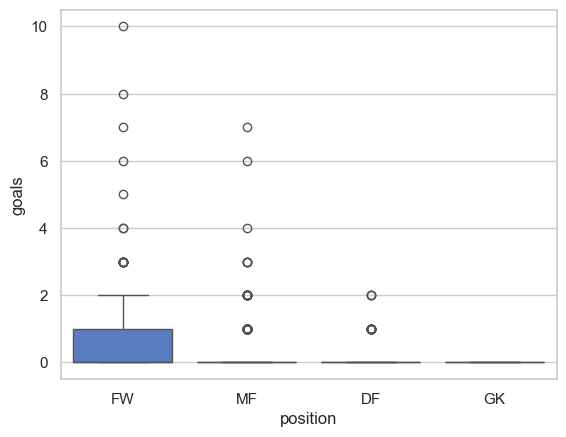

In [19]:
sns.boxplot(x='position', y='goals', data=data)

<Axes: xlabel='position', ylabel='assists'>

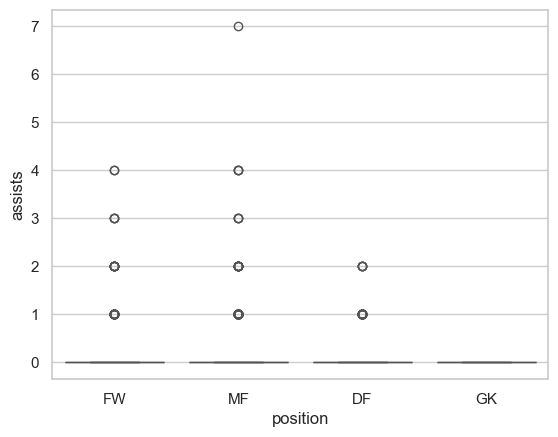

In [20]:
sns.boxplot(x='position', y='assists', data=data)

<Axes: xlabel='position', ylabel='tackles_won'>

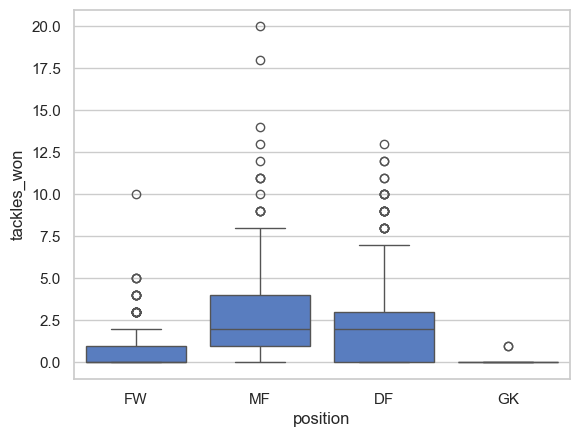

In [21]:
sns.boxplot(x='position', y='tackles_won', data=data)

<Axes: xlabel='position', ylabel='interceptions'>

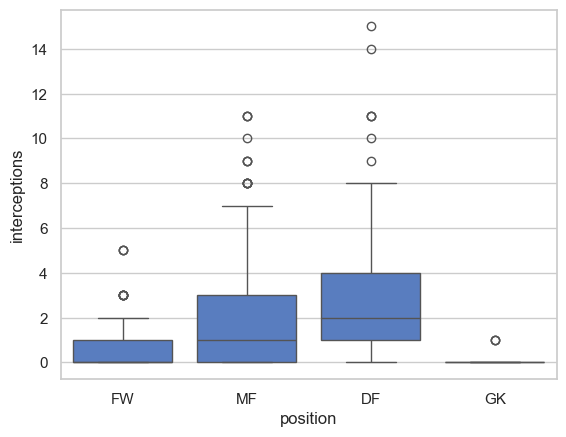

In [22]:
sns.boxplot(x='position', y='interceptions', data=data)

<Axes: xlabel='position', ylabel='crosses'>

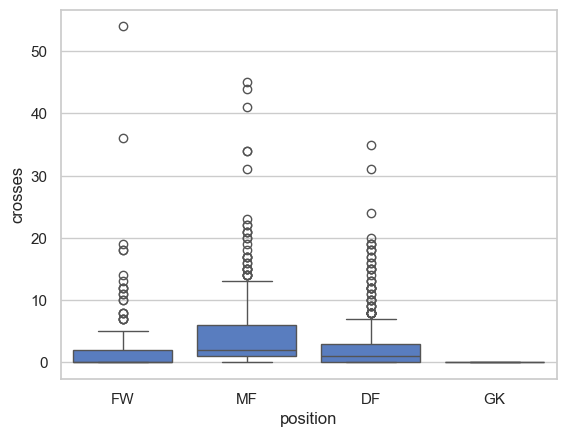

In [23]:
sns.boxplot(x='position', y='crosses', data=data)

In [24]:
data.head()

,player,team,position,age,club,games,minutes,goals,assists,cards_yellow,cards_red,shots,shots_on_target,goals_per_shot,goals_per_shot_on_target,minutes_per_game,fouls,fouled,offsides,crosses,interceptions,tackles_won
1,Adil Boulbina,Algeria,FW,23,Unattached,2,19.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,10.0,0.0,0.0,1.0,0.0,0.0,0.0
2,Amine Gouiri,Algeria,FW,26,Marseille,4,251.0,1.0,0.0,0.0,0.0,3.0,2.0,0.33,0.5,63.0,1.0,1.0,0.0,1.0,0.0,1.0
3,Anis Hadj Moussa,Algeria,MF,24,Feyenoord,3,98.0,0.0,0.0,0.0,0.0,2.0,0.0,0.00,0.0,33.0,0.0,2.0,0.0,5.0,1.0,0.0
4,Aïssa Mandi,Algeria,DF,34,Lille,4,360.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,90.0,0.0,5.0,0.0,0.0,4.0,3.0
5,Fares Chaïbi,Algeria,MF,23,Frankfurt,4,360.0,0.0,0.0,1.0,0.0,9.0,3.0,0.00,0.0,90.0,3.0,2.0,1.0,6.0,3.0,5.0


In [25]:
data['position'].value_counts()

position
MF    392
DF    349
FW    236
GK     62
Name: count, dtype: int64

In [26]:
fouls_per_90_min_per_position = (data.groupby('position')['fouls'].sum() / data.groupby('position')['minutes'].sum())*90

In [27]:
fouled_per_90_min_per_position = (data.groupby('position')['fouled'].sum() / data.groupby('position')['minutes'].sum())*90

In [28]:
fouls_per_90_min_per_position

position
DF    0.982456
FW    1.277140
GK    0.014019
MF    1.205303
dtype: float64

In [29]:
fouled_per_90_min_per_position

position
DF    0.720468
FW    1.331953
GK    0.247664
MF    1.259941
dtype: float64

<Axes: xlabel='position'>

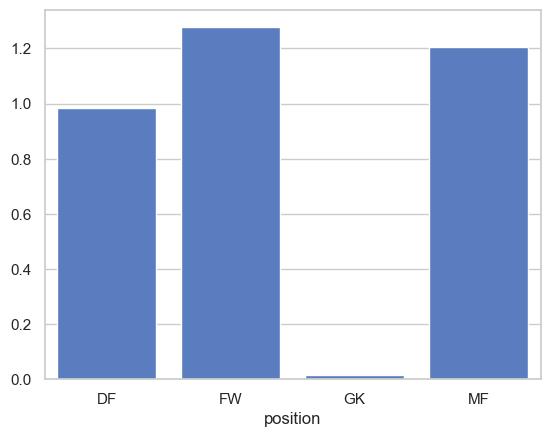

In [30]:
sns.barplot(fouls_per_90_min_per_position)

<Axes: xlabel='position'>

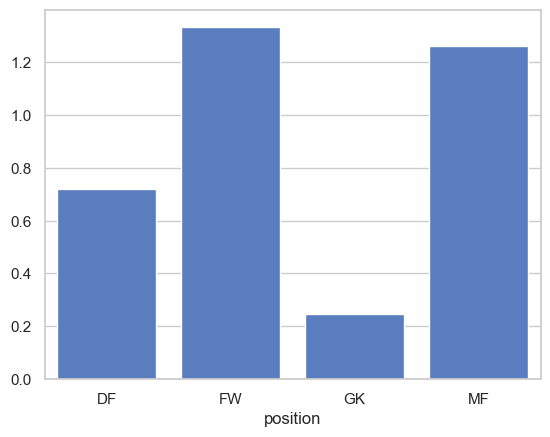

In [31]:
sns.barplot(fouled_per_90_min_per_position)

In [32]:
yellow_per_90_min = (data.groupby('position')['cards_yellow'].sum() / data.groupby('position')['minutes'].sum())*90

In [33]:
yellow_per_90_min

position
DF    0.123977
FW    0.095923
GK    0.014019
MF    0.137687
dtype: float64

<Axes: xlabel='position'>

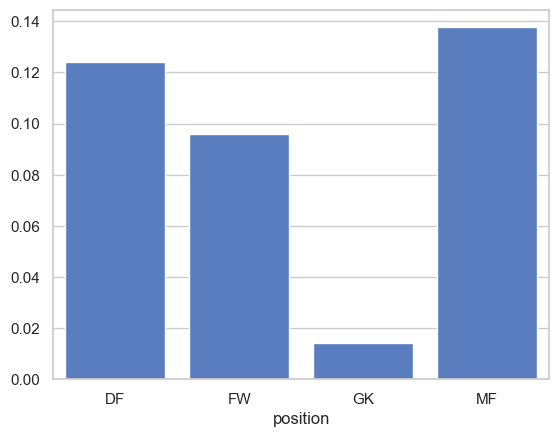

In [34]:
sns.barplot(yellow_per_90_min)

In [35]:
red_per_90_min = (data.groupby('position')['cards_red'].sum() / data.groupby('position')['minutes'].sum())*90

<Axes: xlabel='position'>

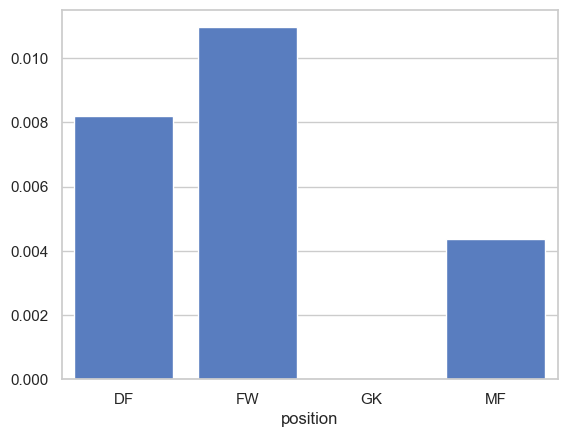

In [36]:
sns.barplot(red_per_90_min)

In [37]:
data.head()

,player,team,position,age,club,games,minutes,goals,assists,cards_yellow,cards_red,shots,shots_on_target,goals_per_shot,goals_per_shot_on_target,minutes_per_game,fouls,fouled,offsides,crosses,interceptions,tackles_won
1,Adil Boulbina,Algeria,FW,23,Unattached,2,19.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,10.0,0.0,0.0,1.0,0.0,0.0,0.0
2,Amine Gouiri,Algeria,FW,26,Marseille,4,251.0,1.0,0.0,0.0,0.0,3.0,2.0,0.33,0.5,63.0,1.0,1.0,0.0,1.0,0.0,1.0
3,Anis Hadj Moussa,Algeria,MF,24,Feyenoord,3,98.0,0.0,0.0,0.0,0.0,2.0,0.0,0.00,0.0,33.0,0.0,2.0,0.0,5.0,1.0,0.0
4,Aïssa Mandi,Algeria,DF,34,Lille,4,360.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,90.0,0.0,5.0,0.0,0.0,4.0,3.0
5,Fares Chaïbi,Algeria,MF,23,Frankfurt,4,360.0,0.0,0.0,1.0,0.0,9.0,3.0,0.00,0.0,90.0,3.0,2.0,1.0,6.0,3.0,5.0


In [38]:
data['goals_per_shot_on_target'] = data['goals'] / data['shots_on_target']

<Axes: xlabel='shots_on_target', ylabel='goals'>

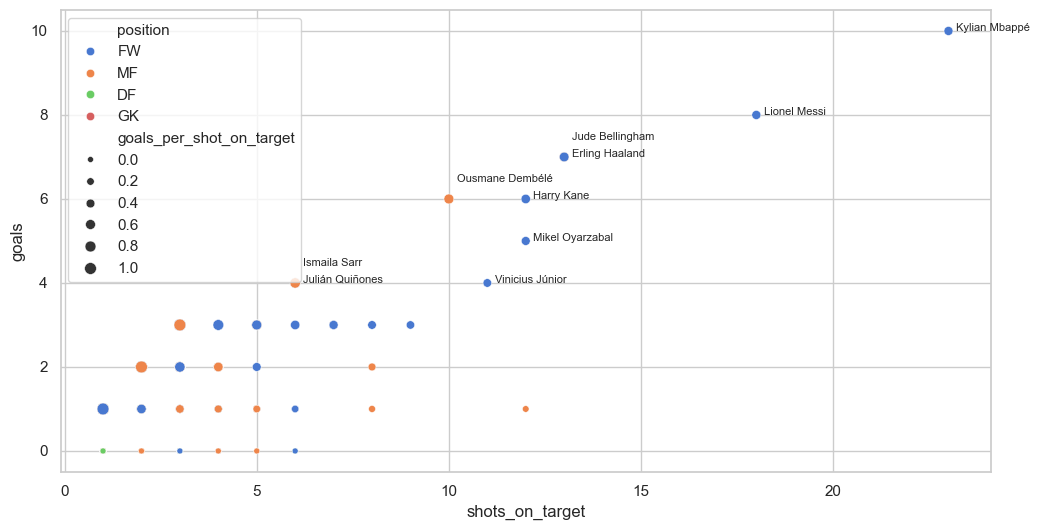

In [39]:
plt.figure(figsize=(12,6))

for idx, row in data[data['goals']>3].iterrows():
    y_offset = 0.4 if idx%2==0 else 0
    plt.text(row['shots_on_target']+0.2, row['goals']+y_offset, row['player'], fontsize=8)
sns.scatterplot(data=data, x='shots_on_target', y='goals', size='goals_per_shot_on_target', hue='position')

In [40]:
data.head()

,player,team,position,age,club,games,minutes,goals,assists,cards_yellow,cards_red,shots,shots_on_target,goals_per_shot,goals_per_shot_on_target,minutes_per_game,fouls,fouled,offsides,crosses,interceptions,tackles_won
1,Adil Boulbina,Algeria,FW,23,Unattached,2,19.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,NaN,10.0,0.0,0.0,1.0,0.0,0.0,0.0
2,Amine Gouiri,Algeria,FW,26,Marseille,4,251.0,1.0,0.0,0.0,0.0,3.0,2.0,0.33,0.5,63.0,1.0,1.0,0.0,1.0,0.0,1.0
3,Anis Hadj Moussa,Algeria,MF,24,Feyenoord,3,98.0,0.0,0.0,0.0,0.0,2.0,0.0,0.00,NaN,33.0,0.0,2.0,0.0,5.0,1.0,0.0
4,Aïssa Mandi,Algeria,DF,34,Lille,4,360.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,NaN,90.0,0.0,5.0,0.0,0.0,4.0,3.0
5,Fares Chaïbi,Algeria,MF,23,Frankfurt,4,360.0,0.0,0.0,1.0,0.0,9.0,3.0,0.00,0.0,90.0,3.0,2.0,1.0,6.0,3.0,5.0


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


([Text(0.9708233610822059, 0.28840931533903885, 'Lautaro Martínez'),
  Text(1.0320650645442528, 0.49700944567016, 'Lionel Messi'),
  Text(0.7471907982756059, 0.28584183673469393, 'Charles De Ketelaere'),
  Text(0.4421659287303656, 0.352181013467137, 'Leandro Trossard'),
  Text(1.243254549501128, 0.39009262503284575, 'Romelu Lukaku'),
  Text(0.08012486992715923, 0.8806907378335951, 'Bruno Guimarães'),
  Text(0.8973051272348878, 0.19115259740259738, 'Vinicius Júnior'),
  Text(0.3051941632768896, 0.6764520705299166, 'Anthony Gordon'),
  Text(0.8149846891913102, 0.7694960665830577, 'Bukayo Saka'),
  Text(0.8949248131100656, 0.13229701389758358, 'Harry Kane'),
  Text(1.1050817848874848, 0.14084000864189328, 'Jude Bellingham'),
  Text(0.7384800988553588, 0.22098214285714285, 'Bradley Barcola'),
  Text(1.3560770031217484, 0.5323351013067097, 'Kylian Mbappé'),
  Text(0.061996618106139434, 0.9905383205913947, 'Michael Olise'),
  Text(1.0532820893213712, 0.34231936017650305, 'Ousmane Dembélé'),


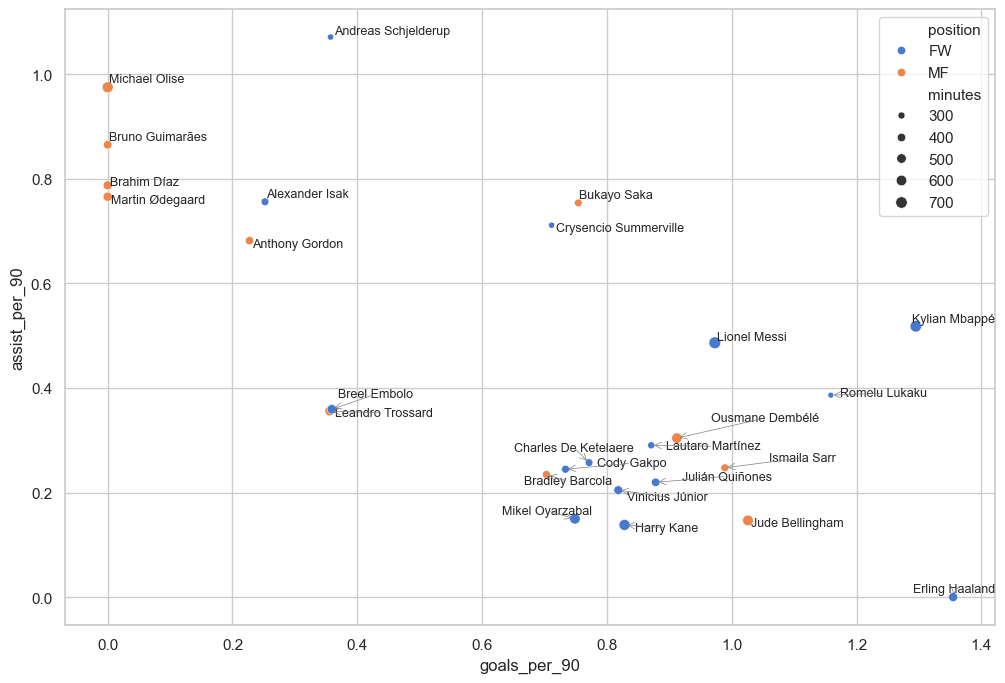

In [41]:
data['goals_per_90'] = (data['goals'] / data['minutes'])*90
data['assist_per_90'] = (data['assists'] / data['minutes'])*90

plt.figure(figsize=(12,8))
texts=[]
temp_data = data[(data['goals']+data['assists']>3) & (data['minutes']>200)]
sns.scatterplot(data=temp_data, x='goals_per_90', y='assist_per_90', size='minutes', hue='position')
for idx, row in temp_data.iterrows():
    texts.append(
    plt.text(row['goals_per_90'], row['assist_per_90'], row['player'], fontsize=9)
    )

adjust_text(
    texts,
    arrowprops=dict(arrowstyle='->', color='gray', lw=0.5),
    expand_text=(1.2, 1.4),                               
    force_text=(0.5, 0.5)                                 
)


([Text(10.126021505376343, 12.244285714285713, 'Alexis Mac Allister'),
  Text(13.029771505376344, 6.244285714285714, 'Enzo Fernández'),
  Text(11.70893817204301, 4.246294642857142, 'Julián Álvarez'),
  Text(3.748266129032258, 20.244285714285713, 'Lionel Messi'),
  Text(10.126021505376343, 15.96142857142857, 'Nicolás Tagliafico'),
  Text(4.796908602150537, 18.244285714285713, 'Jeremy Doku'),
  Text(13.637284946236559, 2.7557142857142853, 'Nicolas Raskin'),
  Text(11.242177419354839, 2.781428571428571, 'Ermedin Demirović'),
  Text(8.859005376344085, 14.244285714285711, 'Richie Laryea'),
  Text(1.9200672043010742, 14.244285714285711, 'Martin Baturina'),
  Text(3.6126881720430104, 12.75671875, 'Tahith Chong'),
  Text(1.8747715053763434, 13.424285714285714, 'Emam Ashour'),
  Text(6.153965053763441, 12.961428571428572, 'Mohamed Salah'),
  Text(9.93662634408602, 13.244285714285715, 'Elliot Anderson'),
  Text(8.484354838709676, 10.755714285714285, 'Ezri Konsa'),
  Text(10.035981182795698, 17.2

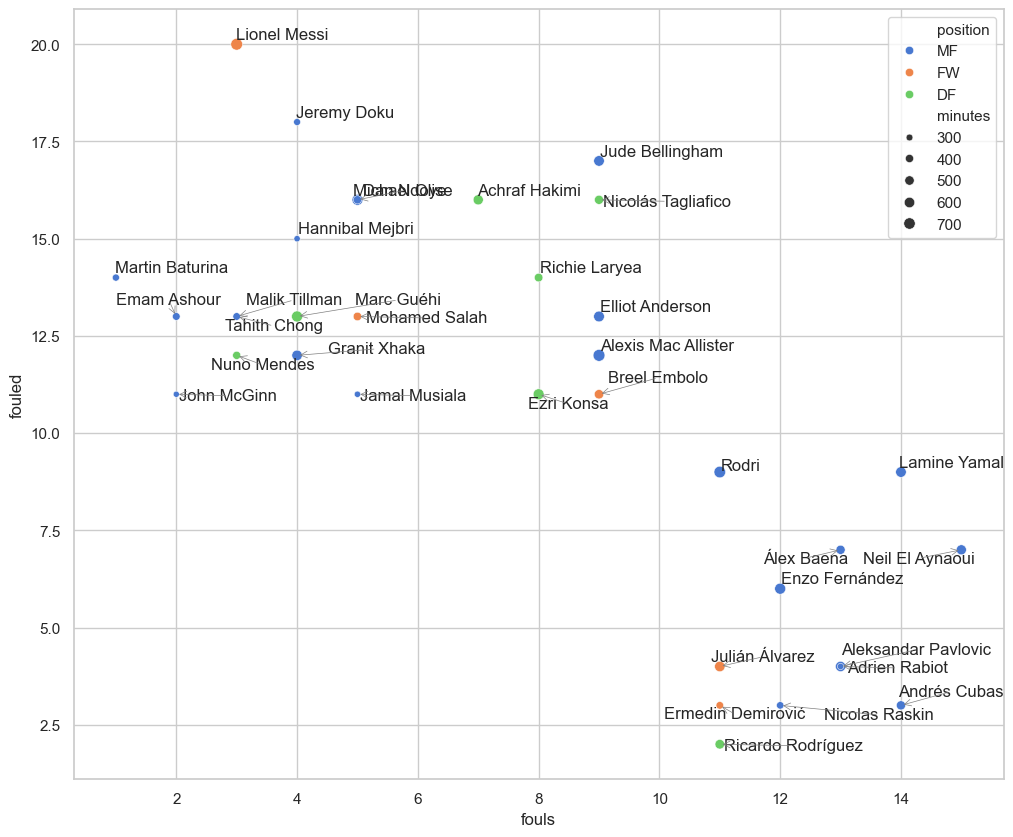

In [42]:
plt.figure(figsize=(12,10))
texts=[]
temp_data = data[((data['fouled']>10) | (data['fouls']>10)) & (data['minutes']>100)]
sns.scatterplot(data=temp_data, x='fouls', y='fouled', size='minutes', hue='position')
for idx, row in temp_data.iterrows():
    texts.append(
    plt.text(row['fouls'], row['fouled'], row['player'], fontsize=12)
    )

adjust_text(
    texts,
    arrowprops=dict(arrowstyle='->', color='gray', lw=0.5),
    expand_text=(1.2, 1.4),                               
    force_text=(0.5, 0.5)                                 
)


In [43]:
data['goals_per_90'] = (data['goals'] / data['minutes'])*90
data['assist_per_90'] = (data['assists'] / data['minutes'])*90

In [44]:
data['cards_per_fouls_per_90'] = (data['cards_yellow'] + data['cards_red']) / data['minutes'] * 90

In [45]:
data.sample(5)

,player,team,position,age,club,games,minutes,goals,assists,cards_yellow,cards_red,shots,shots_on_target,goals_per_shot,goals_per_shot_on_target,minutes_per_game,fouls,fouled,offsides,crosses,interceptions,tackles_won,goals_per_90,assist_per_90,cards_per_fouls_per_90
636,Kento Shiogai,Japan,FW,21,Wolfsburg,1,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
857,Yoel Bárcenas,Panama,MF,32,Mazatlán,3,249.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0,NaN,83.0,3.0,3.0,0.0,7.0,2.0,0.0,0.0,0.0,0.361446
71,Mo Touré,Australia,FW,22,Norwich City,3,165.0,0.0,0.0,0.0,0.0,4.0,1.0,0.0,0.0,55.0,4.0,2.0,1.0,1.0,0.0,1.0,0.0,0.0,0.000000
619,Rebin Sulaka,Iraq,DF,34,Unattached,2,43.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,NaN,22.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.093023
941,Ali Lajami,Saudi Arabia,DF,30,Al-Hilal,3,149.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,50.0,0.0,2.0,0.0,0.0,3.0,2.0,0.0,0.0,0.000000


In [46]:
data['cards_per_fouls_per_90']

1       0.00
2       0.00
3       0.00
4       0.00
5       0.25
        ... 
1242    0.00
1243    0.00
1244    0.00
1245    0.50
1247    0.00
Name: cards_per_fouls_per_90, Length: 1039, dtype: float64

([Text(9.743682795698927, 0.30192307692307685, 'Cristian Romero'),
  Text(11.364639336917564, 0.41558212971438746, 'Enzo Fernández'),
  Text(9.790008960573479, 0.3864201282193938, 'Leandro Paredes'),
  Text(7.822412634408603, 0.29422715442452274, 'Lisandro Martínez'),
  Text(7.614068100358423, 0.5496770918698093, 'Stefan Posch'),
  Text(6.443548387096775, 0.4808044822834434, 'Casemiro'),
  Text(7.2952060931899645, 0.4501052310262835, 'Danilo'),
  Text(2.901758512544804, 0.6261278195488721, 'Sidny Lopes Cabral'),
  Text(8.888328853046598, 0.4896889983954924, 'Luc De Fougerolles'),
  Text(2.558282930107527, 0.7008511403248244, 'Noah Sadiki'),
  Text(4.532997311827958, 0.49444404279930587, 'Ivan Perišić'),
  Text(6.49603494623656, 0.7128545925686413, 'Juninho Bacuna'),
  Text(7.616285842293907, 0.7249936776894733, 'Alan Franco'),
  Text(5.6703741039426525, 0.536843896671563, 'Piero Hincapié'),
  Text(8.597188620071687, 0.42061698912293133, 'Marwan Attia'),
  Text(5.966689068100359, 0.5030

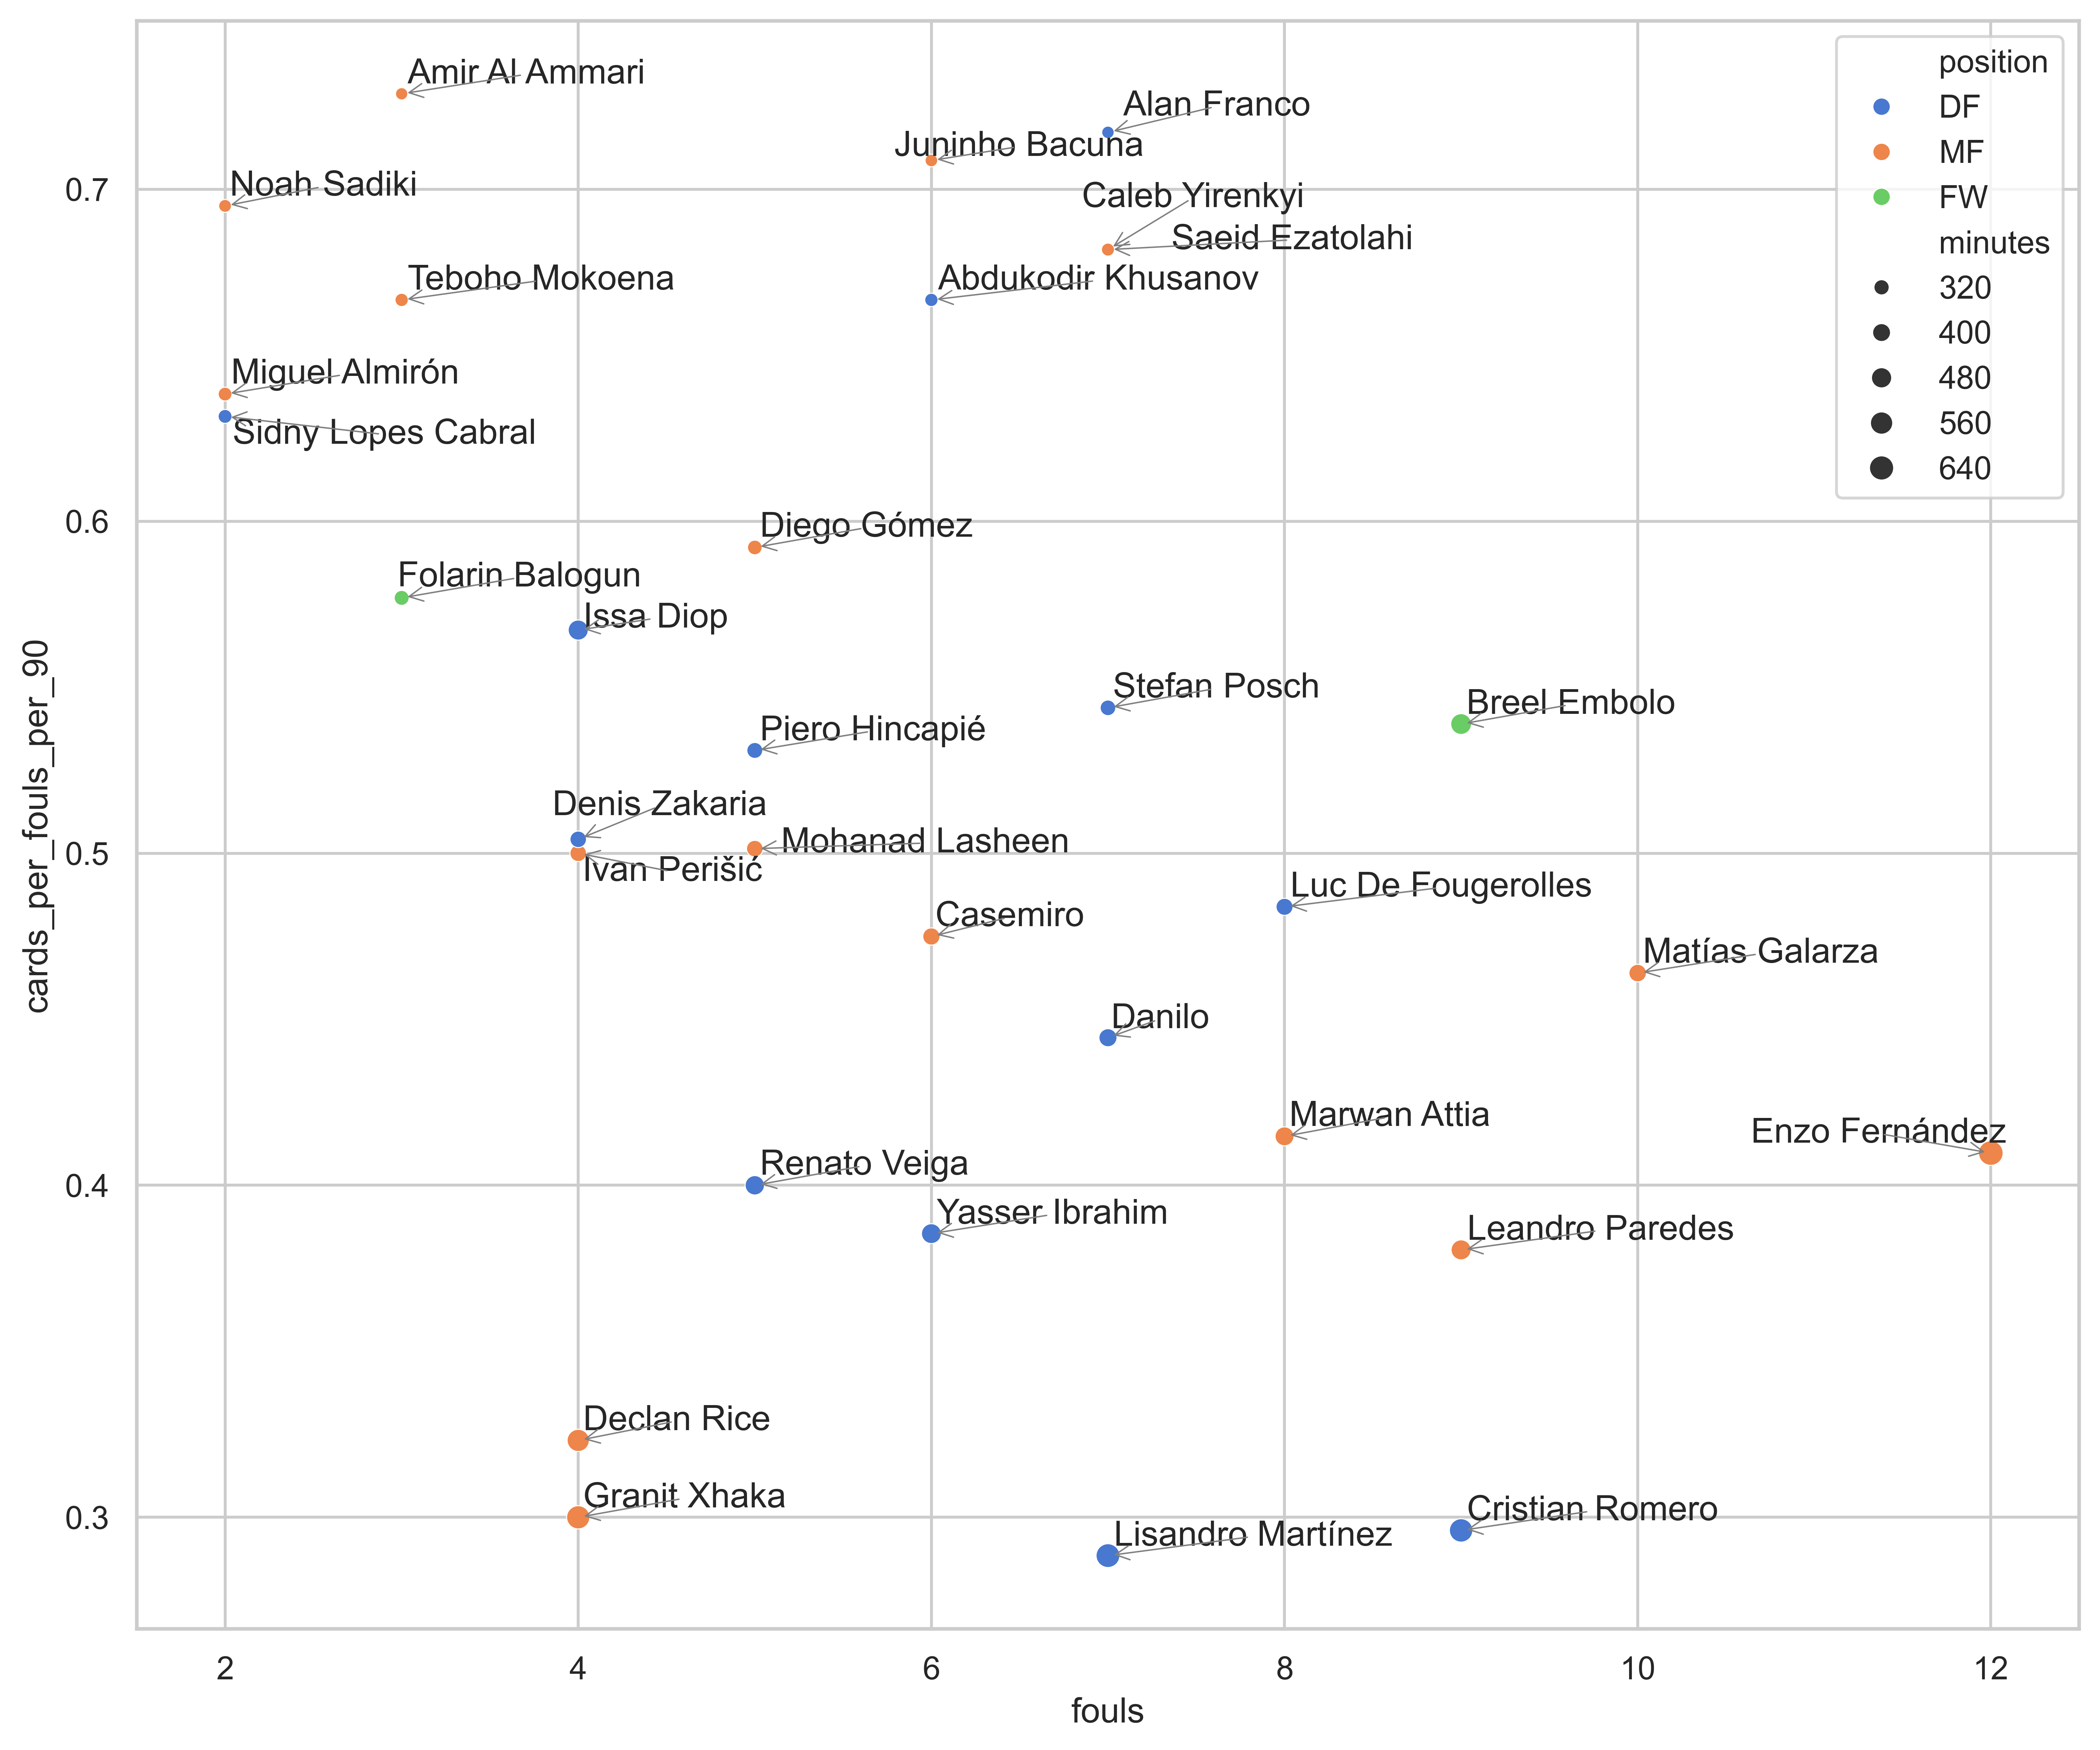

In [47]:
plt.figure(figsize=(12,10), dpi=600)
texts=[]
temp_data = data[((data['cards_yellow'] + data['cards_red'])>1) & (data['minutes']>200)]
sns.scatterplot(data=temp_data, x='fouls', y='cards_per_fouls_per_90', size='minutes', hue='position')
for idx, row in temp_data.iterrows():
    texts.append(
    plt.text(row['fouls'], row['cards_per_fouls_per_90'], row['player'], fontsize=12)
    )

adjust_text(
    texts,
    arrowprops=dict(arrowstyle='->', color='gray', lw=0.5),
    expand_text=(1.2, 1.4),                               
    force_text=(0.5, 0.5)                                 
)


In [48]:
data.head()

,player,team,position,age,club,games,minutes,goals,assists,cards_yellow,cards_red,shots,shots_on_target,goals_per_shot,goals_per_shot_on_target,minutes_per_game,fouls,fouled,offsides,crosses,interceptions,tackles_won,goals_per_90,assist_per_90,cards_per_fouls_per_90
1,Adil Boulbina,Algeria,FW,23,Unattached,2,19.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,NaN,10.0,0.0,0.0,1.0,0.0,0.0,0.0,0.000000,0.0,0.00
2,Amine Gouiri,Algeria,FW,26,Marseille,4,251.0,1.0,0.0,0.0,0.0,3.0,2.0,0.33,0.5,63.0,1.0,1.0,0.0,1.0,0.0,1.0,0.358566,0.0,0.00
3,Anis Hadj Moussa,Algeria,MF,24,Feyenoord,3,98.0,0.0,0.0,0.0,0.0,2.0,0.0,0.00,NaN,33.0,0.0,2.0,0.0,5.0,1.0,0.0,0.000000,0.0,0.00
4,Aïssa Mandi,Algeria,DF,34,Lille,4,360.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,NaN,90.0,0.0,5.0,0.0,0.0,4.0,3.0,0.000000,0.0,0.00
5,Fares Chaïbi,Algeria,MF,23,Frankfurt,4,360.0,0.0,0.0,1.0,0.0,9.0,3.0,0.00,0.0,90.0,3.0,2.0,1.0,6.0,3.0,5.0,0.000000,0.0,0.25


([Text(10.953360215053763, 1.428571428571428, 'Ibrahim Maza'),
  Text(16.42567204301075, 3.8952380952380956, 'Alexis Mac Allister'),
  Text(16.193951612903227, 2.6071428571428568, 'Enzo Fernández'),
  Text(10.909005376344087, 6.676190476190477, 'Julián Álvarez'),
  Text(36.30698924731183, 18.248809523809527, 'Lionel Messi'),
  Text(22.26061827956989, 5.026190476190477, 'Kevin De Bruyne'),
  Text(20.042741935483868, 3.0, 'Leandro Trossard'),
  Text(12.737903225806452, 2.9785714285714286, 'Youri Tielemans'),
  Text(11.068682795698924, 5.340476190476192, 'Matheus Cunha'),
  Text(18.530241935483872, 11.0, 'Vinicius Júnior'),
  Text(19.75793010752688, 8.471428571428573, 'Jonathan David'),
  Text(18.36008064516129, 4.65952380952381, 'Gustavo Puerta'),
  Text(20.13991935483871, 6.4714285714285715, 'Luis Díaz'),
  Text(10.916397849462365, 2.319047619047619, 'Yoane Wissa'),
  Text(12.479973118279569, 0.6857142857142859, 'Omar Marmoush'),
  Text(14.519892473118277, 7.4714285714285715, 'Bukayo Sa

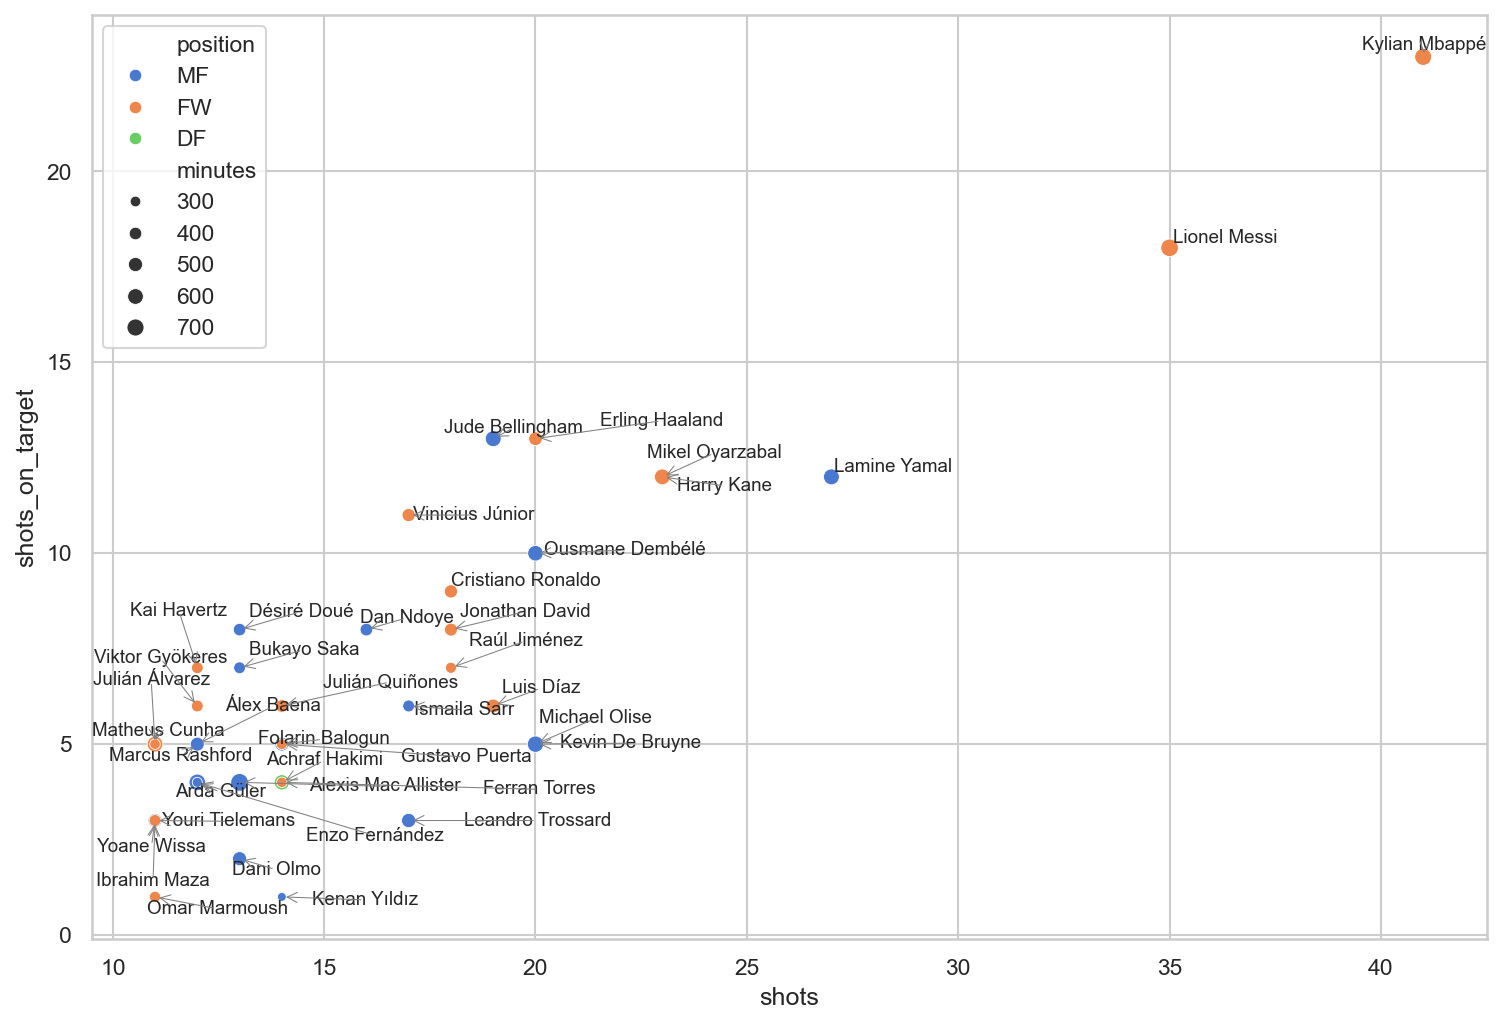

In [49]:
plt.figure(figsize=(12,8), dpi=150)
texts=[]
temp_data = data[(data['minutes']>200)&(data['shots']>10)]
sns.scatterplot(data=temp_data, x='shots', y='shots_on_target', size='minutes', hue='position')
for idx, row in temp_data.iterrows():
    texts.append(
    plt.text(row['shots'], row['shots_on_target'], row['player'], fontsize=9)
    )

adjust_text(
    texts,
    arrowprops=dict(arrowstyle='->', color='gray', lw=0.5),
    expand_text=(1.2, 1.4),                               
    force_text=(0.5, 0.5)                                 
)


In [50]:
data.head()

,player,team,position,age,club,games,minutes,goals,assists,cards_yellow,cards_red,shots,shots_on_target,goals_per_shot,goals_per_shot_on_target,minutes_per_game,fouls,fouled,offsides,crosses,interceptions,tackles_won,goals_per_90,assist_per_90,cards_per_fouls_per_90
1,Adil Boulbina,Algeria,FW,23,Unattached,2,19.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,NaN,10.0,0.0,0.0,1.0,0.0,0.0,0.0,0.000000,0.0,0.00
2,Amine Gouiri,Algeria,FW,26,Marseille,4,251.0,1.0,0.0,0.0,0.0,3.0,2.0,0.33,0.5,63.0,1.0,1.0,0.0,1.0,0.0,1.0,0.358566,0.0,0.00
3,Anis Hadj Moussa,Algeria,MF,24,Feyenoord,3,98.0,0.0,0.0,0.0,0.0,2.0,0.0,0.00,NaN,33.0,0.0,2.0,0.0,5.0,1.0,0.0,0.000000,0.0,0.00
4,Aïssa Mandi,Algeria,DF,34,Lille,4,360.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,NaN,90.0,0.0,5.0,0.0,0.0,4.0,3.0,0.000000,0.0,0.00
5,Fares Chaïbi,Algeria,MF,23,Frankfurt,4,360.0,0.0,0.0,1.0,0.0,9.0,3.0,0.00,0.0,90.0,3.0,2.0,1.0,6.0,3.0,5.0,0.000000,0.0,0.25


([Text(13.714408602150536, 6.232142857142858, 'Rayan Aït-Nouri'),
  Text(12.821451612903227, 9.317261904761905, 'Alexis Mac Allister'),
  Text(10.51510752688172, 9.30952380952381, 'Cristian Romero'),
  Text(11.303440860215053, 2.9380952380952383, 'Lionel Messi'),
  Text(11.858172043010752, 3.278571428571429, 'Douglas Santos'),
  Text(9.713817204301074, 7.814285714285715, 'Richie Laryea'),
  Text(10.088172043010752, 5.123809523809525, 'Jhon Arias'),
  Text(8.709086021505376, 8.417857142857143, 'Samuel Moutoussamy'),
  Text(11.499139784946237, 2.0, 'Pedro Vite'),
  Text(9.711451612903225, 1.9690476190476192, 'Mohamed Hany'),
  Text(11.772956989247312, 5.0, 'Mohanad Lasheen'),
  Text(10.475483870967741, 2.35, 'Djed Spence'),
  Text(18.63279569892473, 9.162500000000001, 'Elliot Anderson'),
  Text(10.53048387096774, 8.504761904761905, 'Jude Bellingham'),
  Text(14.877043010752688, 4.1779761904761905, 'Aurélien Tchouaméni'),
  Text(12.754623655913978, 7.170238095238096, 'Dayot Upamecano'),
 

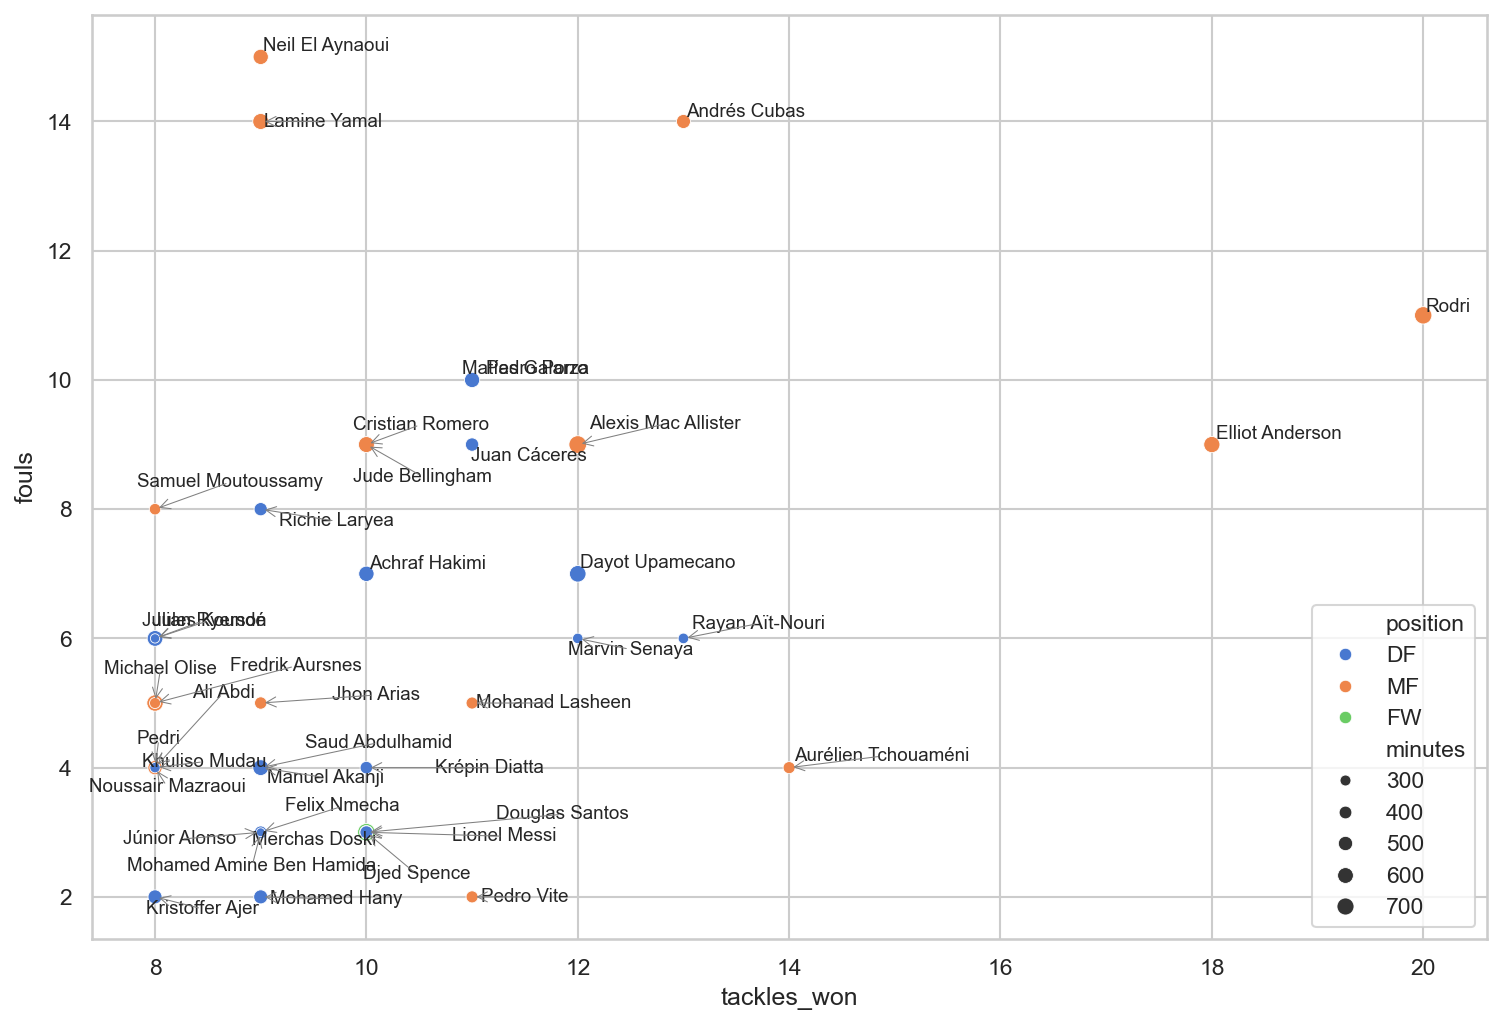

In [51]:
plt.figure(figsize=(12,8), dpi=150)
texts=[]
temp_data = data[(data['minutes']>200)&(data['tackles_won']>7)]
sns.scatterplot(data=temp_data, x='tackles_won', y='fouls', size='minutes', hue='position')
for idx, row in temp_data.iterrows():
    texts.append(
    plt.text(row['tackles_won'], row['fouls'], row['player'], fontsize=9)
    )

adjust_text(
    texts,
    arrowprops=dict(arrowstyle='->', color='gray', lw=0.5),
    expand_text=(1.2, 1.4),                               
    force_text=(0.5, 0.5)                                 
)


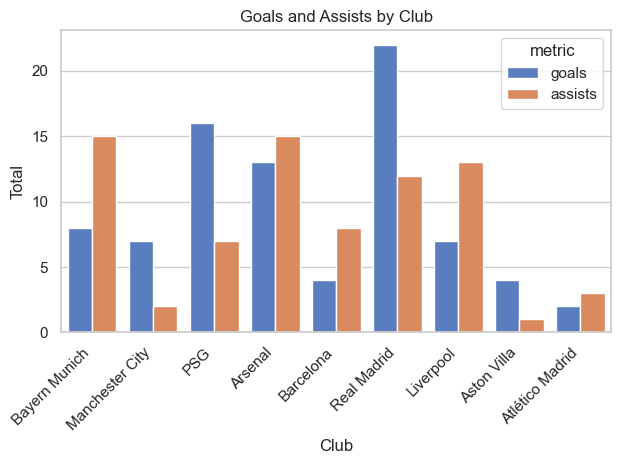

In [52]:
bar_plot_data_club = data.groupby('club').agg({'goals':'sum', 'assists':'sum', 'minutes':'sum'}).sort_values(by='minutes', ascending=False).head(10)
bar_plot_data_club.drop(index='Unattached', inplace=True)

plot_data = (
    bar_plot_data_club[['goals', 'assists']]
    .reset_index()
    .melt(
        id_vars='club',
        var_name='metric',
        value_name='value'
    )
)

sns.barplot(
    data=plot_data,
    x='club',
    y='value',
    hue='metric'
)

plt.xticks(rotation=45, ha='right')
plt.xlabel('Club')
plt.ylabel('Total')
plt.title('Goals and Assists by Club')
plt.tight_layout()

In [53]:
data['bad_discipline'] = (data['cards_yellow'] + data['cards_red']*3) / data['minutes'] * 90

In [54]:
bad_discipline = data.groupby('club').agg({'bad_discipline': 'mean'}).sort_values('bad_discipline', ascending=False).head(10)
bad_discipline

,bad_discipline
club,
Kilmarnock,10.000000
Brentford,3.565215
Espanyol,2.571429
Santos,2.307692
Cultural Leonesa,2.213115
River Plate,1.992188
Sundowns,1.809416
Ind. Rivadavia,1.698113
Corinthians,1.666667


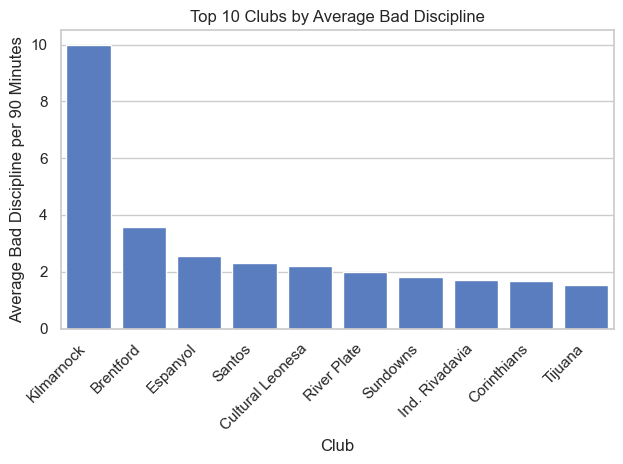

In [55]:
sns.barplot(data=bad_discipline, x=bad_discipline.index, y='bad_discipline')

plt.xticks(rotation=45, ha='right')
plt.xlabel('Club')
plt.ylabel('Average Bad Discipline per 90 Minutes')
plt.title('Top 10 Clubs by Average Bad Discipline')
plt.tight_layout()

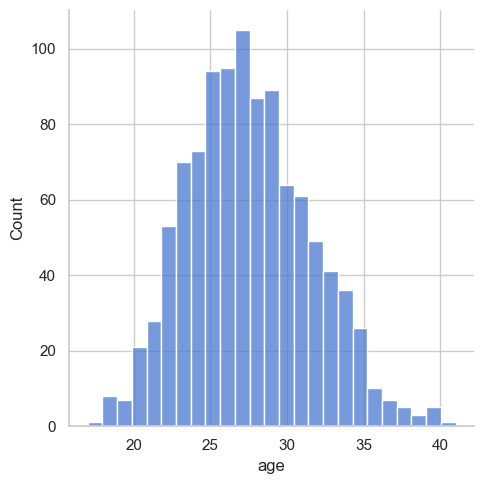

In [56]:
sns.displot(data['age'], bins=25)

In [57]:
data['age_binned'] = pd.cut(data['age'], bins=[15, 20, 25, 30, 35, 40], labels=['16-20', '21-25', '26-30', '31-35', '36-40'])

In [58]:
main_player_data = data[data['minutes']>200]

In [59]:
main_player_data['tackles_won_per_90'] = (main_player_data['tackles_won'] / main_player_data['minutes']) * 90
main_player_data['interceptions_per_90'] = (main_player_data['interceptions'] / main_player_data['minutes']) * 90

In [60]:
_goals_per_90_min = (main_player_data.groupby('age_binned')['goals_per_90'].sum() / main_player_data.groupby('age_binned')['minutes'].sum())*90
_assist_per_90_min = (main_player_data.groupby('age_binned')['assist_per_90'].sum() / main_player_data.groupby('age_binned')['minutes'].sum())*90
_tackles_won_per_90_min = (main_player_data.groupby('age_binned')['tackles_won_per_90'].sum() / main_player_data.groupby('age_binned')['minutes'].sum())*90
_interceptions_per_90_min = (main_player_data.groupby('age_binned')['interceptions_per_90'].sum() / main_player_data.groupby('age_binned')['minutes'].sum())*90 

In [61]:
(data.groupby('age_binned')['goals'].sum() / data.groupby('age_binned')['minutes'].sum())*90

age_binned
16-20    0.114926
21-25    0.154279
26-30    0.128747
31-35    0.074992
36-40    0.164118
dtype: float64

<Axes: xlabel='age_binned'>

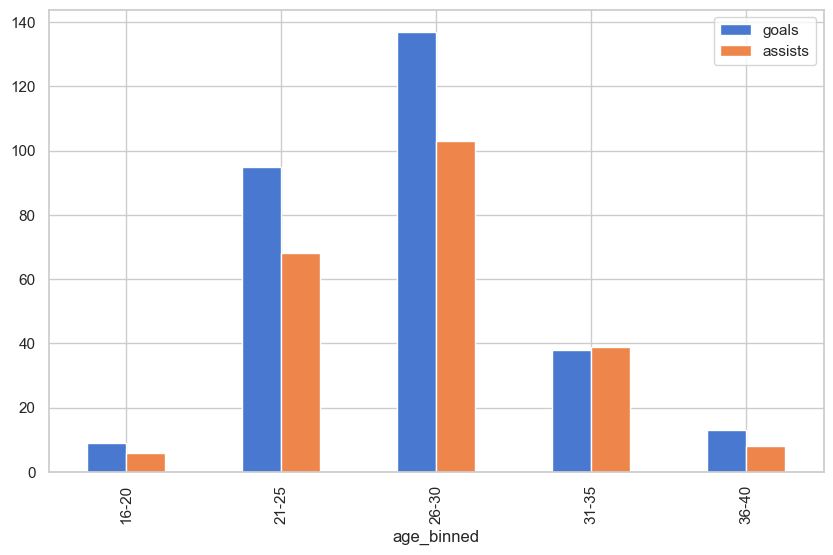

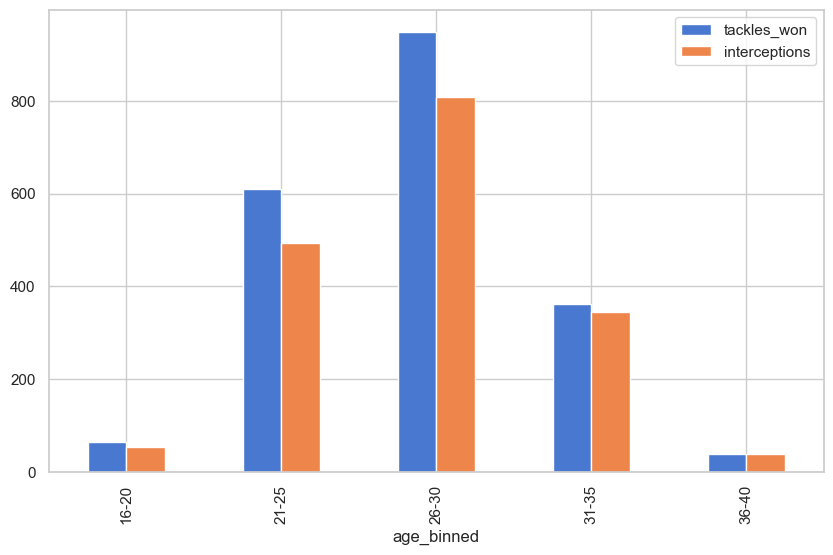

In [62]:
data.groupby('age_binned').agg({'goals': 'sum', 'assists': 'sum'}).reset_index().plot(kind='bar', x='age_binned', y=['goals', 'assists'], figsize=(10,6))
data.groupby('age_binned').agg({'tackles_won': 'sum', 'interceptions': 'sum'}).reset_index().plot(kind='bar', x='age_binned', y=['tackles_won', 'interceptions'], figsize=(10,6))   

<Axes: xlabel='age_binned'>

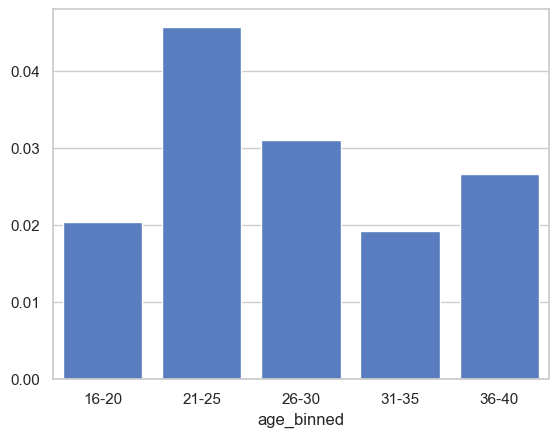

In [63]:
sns.barplot(_goals_per_90_min)

<Axes: xlabel='age_binned'>

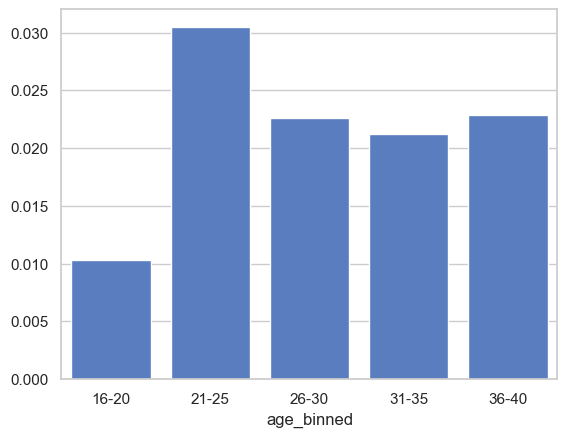

In [64]:
sns.barplot(_assist_per_90_min)

<Axes: xlabel='age_binned'>

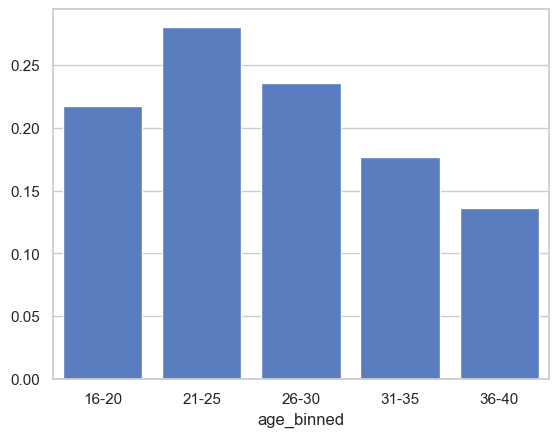

In [65]:
sns.barplot(_tackles_won_per_90_min)

<Axes: xlabel='age_binned'>

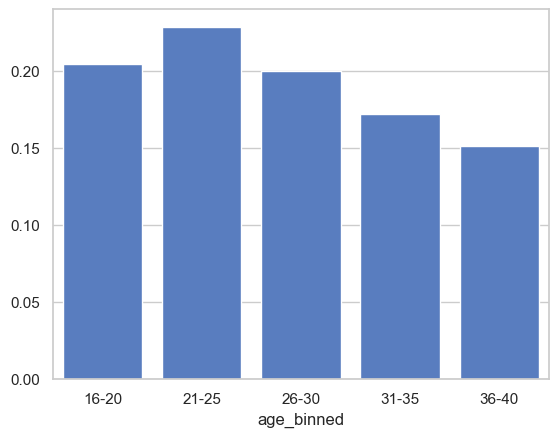

In [66]:
sns.barplot(_interceptions_per_90_min)

In [67]:
corr_matrix = data[['fouls','fouled','age']].corr()

<Axes: >

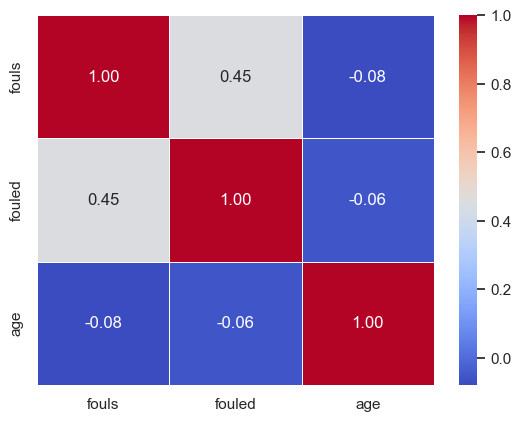

In [68]:
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

In [72]:
data.head()

,player,team,position,age,club,games,minutes,goals,assists,cards_yellow,cards_red,shots,shots_on_target,goals_per_shot,goals_per_shot_on_target,minutes_per_game,fouls,fouled,offsides,crosses,interceptions,tackles_won,goals_per_90,assist_per_90,cards_per_fouls_per_90,bad_discipline,age_binned
1,Adil Boulbina,Algeria,FW,23,Unattached,2,19.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,NaN,10.0,0.0,0.0,1.0,0.0,0.0,0.0,0.000000,0.0,0.00,0.00,21-25
2,Amine Gouiri,Algeria,FW,26,Marseille,4,251.0,1.0,0.0,0.0,0.0,3.0,2.0,0.33,0.5,63.0,1.0,1.0,0.0,1.0,0.0,1.0,0.358566,0.0,0.00,0.00,26-30
3,Anis Hadj Moussa,Algeria,MF,24,Feyenoord,3,98.0,0.0,0.0,0.0,0.0,2.0,0.0,0.00,NaN,33.0,0.0,2.0,0.0,5.0,1.0,0.0,0.000000,0.0,0.00,0.00,21-25
4,Aïssa Mandi,Algeria,DF,34,Lille,4,360.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,NaN,90.0,0.0,5.0,0.0,0.0,4.0,3.0,0.000000,0.0,0.00,0.00,31-35
5,Fares Chaïbi,Algeria,MF,23,Frankfurt,4,360.0,0.0,0.0,1.0,0.0,9.0,3.0,0.00,0.0,90.0,3.0,2.0,1.0,6.0,3.0,5.0,0.000000,0.0,0.25,0.25,21-25


In [75]:
data.info()

<class 'pandas.DataFrame'>
Index: 1039 entries, 1 to 1247
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   player                    1039 non-null   str     
 1   team                      1039 non-null   str     
 2   position                  1039 non-null   object  
 3   age                       1039 non-null   int64   
 4   club                      1039 non-null   str     
 5   games                     1039 non-null   int64   
 6   minutes                   1039 non-null   float64 
 7   goals                     1039 non-null   float64 
 8   assists                   1039 non-null   float64 
 9   cards_yellow              1039 non-null   float64 
 10  cards_red                 1039 non-null   float64 
 11  shots                     1039 non-null   float64 
 12  shots_on_target           1039 non-null   float64 
 13  goals_per_shot            1039 non-null   float64 
 14  goals_pe

In [ ]:
data['goals_per_shot_on_target'] = data['goals_per_shot_on_target'].fillna(0)

data['position'] = data['position'].astype('category')

# 3. Downcast whole-number metrics to int16 (2 bytes instead of 8 bytes)
int16_cols = [
    'age', 'games', 'minutes', 'goals', 'assists', 
    'cards_yellow', 'cards_red', 'shots', 'shots_on_target', 
    'fouls', 'fouled', 'offsides', 'crosses', 'interceptions', 'tackles_won'
]
for col in int16_cols:
    if col in data.columns:
        data[col] = data[col].fillna(0).astype('int16')
# 4. Downcast decimal ratios/rates from float64 to float32 (cut memory in half)
float16_cols = [
    'goals_per_shot', 'goals_per_shot_on_target', 'minutes_per_game',
    'goals_per_90', 'assist_per_90', 'cards_per_fouls_per_90', 'bad_discipline'
]
for col in float16_cols:
    if col in data.columns:
        data[col] = data[col].fillna(0.0).astype('float16')

In [77]:
data.info()

<class 'pandas.DataFrame'>
Index: 1039 entries, 1 to 1247
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   player                    1039 non-null   str     
 1   team                      1039 non-null   str     
 2   position                  1039 non-null   category
 3   age                       1039 non-null   int16   
 4   club                      1039 non-null   str     
 5   games                     1039 non-null   int16   
 6   minutes                   1039 non-null   int16   
 7   goals                     1039 non-null   int16   
 8   assists                   1039 non-null   int16   
 9   cards_yellow              1039 non-null   int16   
 10  cards_red                 1039 non-null   int16   
 11  shots                     1039 non-null   int16   
 12  shots_on_target           1039 non-null   int16   
 13  goals_per_shot            1039 non-null   float16 
 14  goals_pe

In [78]:
data.to_csv("cleaned_players.csv", index=False)

In [79]:
data.head()

c:\Users\lenovo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\io\formats\format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,player,team,position,age,club,games,minutes,goals,assists,cards_yellow,cards_red,shots,shots_on_target,goals_per_shot,goals_per_shot_on_target,minutes_per_game,fouls,fouled,offsides,crosses,interceptions,tackles_won,goals_per_90,assist_per_90,cards_per_fouls_per_90,bad_discipline,age_binned
1,Adil Boulbina,Algeria,FW,23,Unattached,2,19,0,0,0,0,0,0,0.000000,0.0,10.0,0,0,1,0,0,0,0.000000,0.0,0.00,0.00,21-25
2,Amine Gouiri,Algeria,FW,26,Marseille,4,251,1,0,0,0,3,2,0.330078,0.5,63.0,1,1,0,1,0,1,0.358643,0.0,0.00,0.00,26-30
3,Anis Hadj Moussa,Algeria,MF,24,Feyenoord,3,98,0,0,0,0,2,0,0.000000,0.0,33.0,0,2,0,5,1,0,0.000000,0.0,0.00,0.00,21-25
4,Aïssa Mandi,Algeria,DF,34,Lille,4,360,0,0,0,0,0,0,0.000000,0.0,90.0,0,5,0,0,4,3,0.000000,0.0,0.00,0.00,31-35
5,Fares Chaïbi,Algeria,MF,23,Frankfurt,4,360,0,0,1,0,9,3,0.000000,0.0,90.0,3,2,1,6,3,5,0.000000,0.0,0.25,0.25,21-25
